# nnUNet v2 - Aorta Segmentation Setup

This notebook sets up and trains nnUNet v2 for aortic segmentation from MRI data.

## 1. Import Packages

In [14]:
import os
import sys
import json
import shutil
import random
from collections import OrderedDict
from glob import glob

import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

import torch

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.11.0+cu126
CUDA available: True
CUDA device: NVIDIA GeForce RTX 3050 Ti Laptop GPU


## 2. Setup Directories and Environment Variables

In [15]:
BASE_DIR = os.path.dirname(os.path.abspath(os.getcwd()))
print(f"Project base directory: {BASE_DIR}")

RAW_DATA_DIR = os.path.join(BASE_DIR, 'data')
NNUNET_RAW = os.path.join(BASE_DIR, 'nnUNet_raw')
NNUNET_PREPROCESSED = os.path.join(BASE_DIR, 'nnUNet_preprocessed')
NNUNET_RESULTS = os.path.join(BASE_DIR, 'nnUNet_results')

for d in [NNUNET_RAW, NNUNET_PREPROCESSED, NNUNET_RESULTS]:
    os.makedirs(d, exist_ok=True)

os.environ['nnUNet_raw'] = NNUNET_RAW
os.environ['nnUNet_preprocessed'] = NNUNET_PREPROCESSED
os.environ['nnUNet_results'] = NNUNET_RESULTS

print(f"nnUNet_raw: {NNUNET_RAW}")
print(f"nnUNet_preprocessed: {NNUNET_PREPROCESSED}")
print(f"nnUNet_results: {NNUNET_RESULTS}")

Project base directory: d:\projects\4D-flow-MRI-aortic-segmentation-
nnUNet_raw: d:\projects\4D-flow-MRI-aortic-segmentation-\nnUNet_raw
nnUNet_preprocessed: d:\projects\4D-flow-MRI-aortic-segmentation-\nnUNet_preprocessed
nnUNet_results: d:\projects\4D-flow-MRI-aortic-segmentation-\nnUNet_results


## 3. Create Dataset Directory Structure

In [16]:
DATASET_ID = 101
DATASET_NAME = 'AORTA_MRI'
DATASET_DIR = os.path.join(NNUNET_RAW, f"Dataset{DATASET_ID}_{DATASET_NAME}")
IMAGES_TR = os.path.join(DATASET_DIR, 'imagesTr')
LABELS_TR = os.path.join(DATASET_DIR, 'labelsTr')
IMAGES_TS = os.path.join(DATASET_DIR, 'imagesTs')

for d in [DATASET_DIR, IMAGES_TR, LABELS_TR, IMAGES_TS]:
    os.makedirs(d, exist_ok=True)

print(f"Dataset directory: {DATASET_DIR}")
print(f"Images training: {IMAGES_TR}")
print(f"Labels training: {LABELS_TR}")
print(f"Images test: {IMAGES_TS}")

Dataset directory: d:\projects\4D-flow-MRI-aortic-segmentation-\nnUNet_raw\Dataset101_AORTA_MRI
Images training: d:\projects\4D-flow-MRI-aortic-segmentation-\nnUNet_raw\Dataset101_AORTA_MRI\imagesTr
Labels training: d:\projects\4D-flow-MRI-aortic-segmentation-\nnUNet_raw\Dataset101_AORTA_MRI\labelsTr
Images test: d:\projects\4D-flow-MRI-aortic-segmentation-\nnUNet_raw\Dataset101_AORTA_MRI\imagesTs


## 4. Convert Data to nnUNet Format

Convert your local data (ao_imgs/ and ao_segs/) to nnUNet v2 format.

In [17]:
IMAGES_SOURCE = os.path.join(RAW_DATA_DIR, 'ao_imgs')
LABELS_SOURCE = os.path.join(RAW_DATA_DIR, 'ao_segs')

print(f"Source images: {IMAGES_SOURCE}")
print(f"Source labels: {LABELS_SOURCE}")

image_files = sorted(glob(os.path.join(IMAGES_SOURCE, '*.nii.gz')))
label_files = sorted(glob(os.path.join(LABELS_SOURCE, '*.nii.gz')))

print(f"Found {len(image_files)} images")
print(f"Found {len(label_files)} labels")

Source images: d:\projects\4D-flow-MRI-aortic-segmentation-\data\ao_imgs
Source labels: d:\projects\4D-flow-MRI-aortic-segmentation-\data\ao_segs
Found 744 images
Found 744 labels


In [18]:
def copy_file(src, dst):
    os.makedirs(os.path.dirname(dst), exist_ok=True)
    shutil.copy2(src, dst)

processed_count = 0
skipped_count = 0
errors = []

for img_path in image_files:
    img_name = os.path.basename(img_path)
    
    label_name = img_name.replace('_0000', '')
    label_path = os.path.join(LABELS_SOURCE, label_name)
    
    if not os.path.exists(label_path):
        errors.append(f"Missing label for {img_name}: {label_path}")
        skipped_count += 1
        continue
    
    dst_img = os.path.join(IMAGES_TR, img_name)
    dst_label = os.path.join(LABELS_TR, label_name)
    
    if not os.path.exists(dst_img):
        copy_file(img_path, dst_img)
    if not os.path.exists(dst_label):
        copy_file(label_path, dst_label)
    
    processed_count += 1

print(f"Processed: {processed_count} image-label pairs")
print(f"Skipped: {skipped_count}")

if errors:
    print(f"\nErrors ({len(errors)}):")
    for e in errors[:10]:
        print(f"  - {e}")

Processed: 744 image-label pairs
Skipped: 0


In [19]:
print(f"\nVerification:")
print(f"imagesTr: {len(os.listdir(IMAGES_TR))} files")
print(f"labelsTr: {len(os.listdir(LABELS_TR))} files")


Verification:
imagesTr: 744 files
labelsTr: 744 files


## 5. Create dataset.json

In [20]:
train_entries = []
label_files = sorted([f for f in os.listdir(LABELS_TR) if f.endswith('.nii.gz')])

for lab in label_files:
    img_name = lab.replace('.nii.gz', '_0000.nii.gz')
    img_path = os.path.join(IMAGES_TR, img_name)
    lab_path = os.path.join(LABELS_TR, lab)
    
    if os.path.isfile(img_path):
        train_entries.append({
            "image": f"./imagesTr/{img_name}",
            "label": f"./labelsTr/{lab}"
        })

print(f"Created {len(train_entries)} training entries")

Created 744 training entries


In [21]:
dataset_dict = OrderedDict()
dataset_dict["name"] = DATASET_NAME
dataset_dict["description"] = "Aorta Segmentation from 4D Flow MRI"
dataset_dict["tensorImageSize"] = "3D"
dataset_dict["reference"] = ""
dataset_dict["licence"] = ""
dataset_dict["release"] = "0.0"
dataset_dict["modality"] = {"0": "MRI"}
dataset_dict["channel_names"] = {"0": "MRI"}
dataset_dict["file_ending"] = ".nii.gz"
dataset_dict["labels"] = {
    "background": 0,
    "aorta": 1
}
dataset_dict["numTraining"] = len(train_entries)
dataset_dict["training"] = train_entries

dataset_json_path = os.path.join(DATASET_DIR, 'dataset.json')
with open(dataset_json_path, 'w') as f:
    json.dump(dataset_dict, f, indent=4)

print(f"Created dataset.json at: {dataset_json_path}")

Created dataset.json at: d:\projects\4D-flow-MRI-aortic-segmentation-\nnUNet_raw\Dataset101_AORTA_MRI\dataset.json


## 6. Data Verification

Sample image shape: (186, 240, 48)
Sample label shape: (186, 240, 48)
Image dtype: float64
Label dtype: uint8
Label unique values: [0 1]


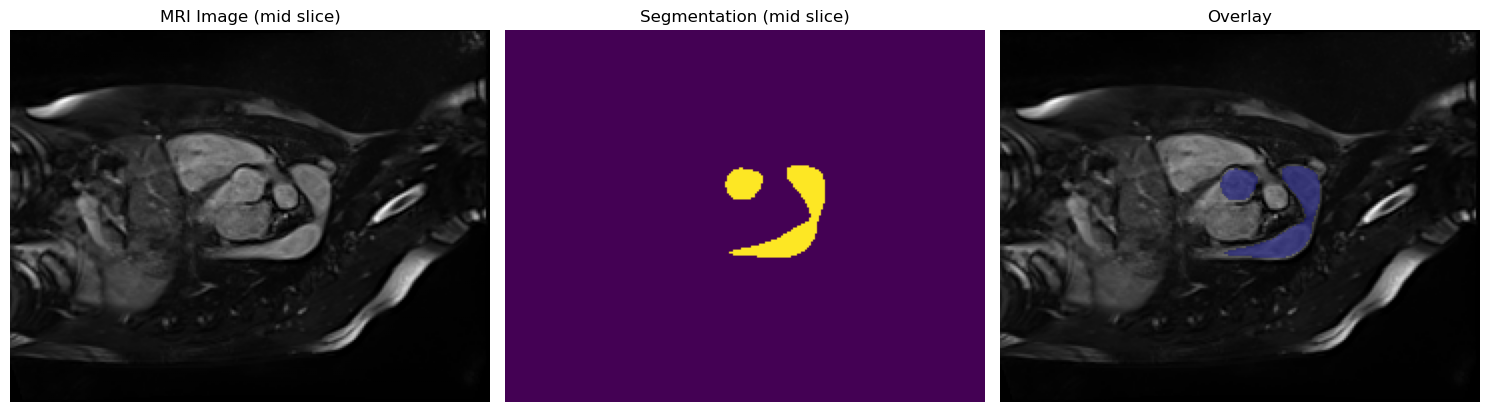

In [22]:
if train_entries:
    sample = random.choice(train_entries)
    img_nii = nib.load(os.path.join(DATASET_DIR, sample["image"][2:]))
    lab_nii = nib.load(os.path.join(DATASET_DIR, sample["label"][2:]))
    img_data = np.asarray(img_nii.dataobj)
    lab_data = np.asarray(lab_nii.dataobj)
    print(f"Sample image shape: {img_data.shape}")
    print(f"Sample label shape: {lab_data.shape}")
    print(f"Image dtype: {img_data.dtype}")
    print(f"Label dtype: {lab_data.dtype}")
    print(f"Label unique values: {np.unique(lab_data)}")
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    z = img_data.shape[-1] // 2
    axes[0].imshow(img_data[:, :, z], cmap='gray')
    axes[0].set_title('MRI Image (mid slice)')
    axes[0].axis('off')
    
    axes[1].imshow(lab_data[:, :, z])
    axes[1].set_title('Segmentation (mid slice)')
    axes[1].axis('off')
    
    overlay = np.zeros_like(img_data)
    overlay[:, :, z] = img_data[:, :, z]
    masked = np.ma.masked_where(lab_data[:, :, z] == 0, lab_data[:, :, z])
    axes[2].imshow(img_data[:, :, z], cmap='gray')
    axes[2].imshow(masked, cmap='jet', alpha=0.5)
    axes[2].set_title('Overlay')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

## 7. Run nnUNet Preprocessing

Plan and preprocess the dataset. This will create the training configurations.

In [23]:
# This is a floating-point precision mismatch between image and label spacings. Add this code before running preprocessing to fix it:

IMAGES_TR = os.path.join(DATASET_DIR, 'imagesTr')
LABELS_TR = os.path.join(DATASET_DIR, 'labelsTr')
fixed_count = 0
for label_file in os.listdir(LABELS_TR):
    if not label_file.endswith('.nii.gz'):
        continue
    
    image_name = label_file.replace('.nii.gz', '_0000.nii.gz')
    image_path = os.path.join(IMAGES_TR, image_name)
    label_path = os.path.join(LABELS_TR, label_file)
    
    if not os.path.exists(image_path):
        continue
    
    img_nii = nib.load(image_path)
    lab_nii = nib.load(label_path)
    
    img_spacing = img_nii.header.get_zooms()
    lab_spacing = lab_nii.header.get_zooms()
    
    if not np.allclose(img_spacing, lab_spacing, rtol=1e-5):
        new_lab = nib.Nifti1Image(lab_nii.dataobj, img_nii.affine, img_nii.header)
        new_lab.header.set_zooms(img_spacing)
        nib.save(new_lab, label_path)
        fixed_count += 1
        print(f"Fixed: {label_file} | Old: {lab_spacing} -> New: {img_spacing}")
print(f"\nFixed spacing for {fixed_count} label files")

Fixed: AORTA_103333.nii.gz | Old: (np.float32(1.5000348), np.float32(1.83333), np.float32(1.83333)) -> New: (np.float32(1.5), np.float32(1.83333), np.float32(1.83333))
Fixed: AORTA_103971.nii.gz | Old: (np.float32(1.5000592), np.float32(1.8333302), np.float32(1.83333)) -> New: (np.float32(1.5), np.float32(1.83333), np.float32(1.83333))
Fixed: AORTA_107686.nii.gz | Old: (np.float32(1.4999739), np.float32(1.83333), np.float32(1.83333)) -> New: (np.float32(1.5), np.float32(1.83333), np.float32(1.83333))
Fixed: AORTA_107693.nii.gz | Old: (np.float32(1.5000454), np.float32(1.4583302), np.float32(1.4583302)) -> New: (np.float32(1.5), np.float32(1.45833), np.float32(1.45833))
Fixed: AORTA_107805.nii.gz | Old: (np.float32(1.4999835), np.float32(1.8333302), np.float32(1.83333)) -> New: (np.float32(1.5), np.float32(1.83333), np.float32(1.83333))
Fixed: AORTA_108328.nii.gz | Old: (np.float32(1.4999225), np.float32(1.8333299), np.float32(1.83333)) -> New: (np.float32(1.5), np.float32(1.83333), np.

In [24]:
import subprocess

print("Running nnUNetv2_plan_and_preprocess...")
print(f"Dataset ID: {DATASET_ID}")

cmd = f"nnUNetv2_plan_and_preprocess -d {DATASET_ID} -c 3d_fullres --verify_dataset_integrity"
print(f"Command: {cmd}")

result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
print("\n--- STDOUT ---")
print(result.stdout)
if result.stderr:
    print("\n--- STDERR ---")
    print(result.stderr)
print(f"\nReturn code: {result.returncode}")

Running nnUNetv2_plan_and_preprocess...
Dataset ID: 101
Command: nnUNetv2_plan_and_preprocess -d 101 -c 3d_fullres --verify_dataset_integrity

--- STDOUT ---
Fingerprint extraction...
Dataset101_AORTA_MRI
Using <class 'nnunetv2.imageio.simpleitk_reader_writer.SimpleITKIO'> as reader/writer

####################
verify_dataset_integrity Done. 
If you didn't see any error messages then your dataset is most likely OK!
####################

Using <class 'nnunetv2.imageio.simpleitk_reader_writer.SimpleITKIO'> as reader/writer
Experiment planning...

############################
INFO: You are using the old nnU-Net default planner. We have updated our recommendations. Please consider using those instead! Read more here: https://github.com/MIC-DKFZ/nnUNet/blob/master/documentation/resenc_presets.md
############################

Dropping 3d_lowres config because the image size difference to 3d_fullres is too small. 3d_fullres: [217.  72. 179.], 3d_lowres: [217, 72, 179]
2D U-Net configuration:


## 8. Train the Model

Train nnUNet using 3D full resolution configuration.

### error result explanation
There is a common OpenMP runtime conflict on Windows. This error occurs when multiple copies of the Intel OpenMP library are linked.
The user needs to set an environment variable to work around this issue.
Add this at the beginning of your notebook (before importing torch) or run in terminal before training:
set KMP_DUPLICATE_LIB_OK=TRUE

In [ ]:

# os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

In [26]:
FOLD = 0  # Change to train different folds (0-4)

print(f"Training nnUNet v2 - Dataset {DATASET_ID}, Fold {FOLD}")
print(f"Configuration: 3d_fullres")

cmd = f"nnUNetv2_train {DATASET_ID} 3d_fullres {FOLD}"
print(f"Command: {cmd}")

result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
print("\n--- STDOUT ---")
print(result.stdout[-10000:] if len(result.stdout) > 10000 else result.stdout)
if result.stderr:
    print("\n--- STDERR ---")
    print(result.stderr[-5000:] if len(result.stderr) > 5000 else result.stderr)
print(f"\nReturn code: {result.returncode}")

Training nnUNet v2 - Dataset 101, Fold 0
Configuration: 3d_fullres
Command: nnUNetv2_train 101 3d_fullres 0

--- STDOUT ---

############################
INFO: You are using the old nnU-Net default plans. We have updated our recommendations. Please consider using those instead! Read more here: https://github.com/MIC-DKFZ/nnUNet/blob/master/documentation/resenc_presets.md
############################

Using device: cuda:0

#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

2026-04-05 13:16:54.735999: do_dummy_2d_data_aug: False


--- STDERR ---
Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File

## 9. Inference on New Images

After training, use this code to run inference on new images.

In [ ]:
def run_inference(input_image, output_path, dataset_id=DATASET_ID):
    """
    Run nnUNet inference on a single image.
    
    Args:
        input_image: Path to input .nii.gz image
        output_path: Path to save prediction
        dataset_id: Dataset ID used for training
    """
    cmd = f'nnUNetv2_predict -i "{os.path.dirname(input_image)}" -o "{output_path}" -d {dataset_id} -c 3d_fullres -f 0'
    print(f"Running: {cmd}")
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    print(result.stdout)
    if result.stderr:
        print(result.stderr)
    return result.returncode == 0

# Example usage:
# run_inference('/path/to/your/image.nii.gz', '/path/to/output/')

## 10. Training All Folds (Optional)

Run this cell to train all 5 folds for cross-validation.

In [ ]:
# Train all 5 folds
for fold in range(5):
    print(f"\n{'='*50}")
    print(f"Training Fold {fold}")
    print(f"{'='*50}")
    
    cmd = f"nnUNetv2_train {DATASET_ID} 3d_fullres {fold}"
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    
    if result.returncode == 0:
        print(f"Fold {fold} completed successfully!")
    else:
        print(f"Fold {fold} failed with return code {result.returncode}")
        print(result.stderr[-2000:] if result.stderr else "")
        break